# Beadandó házifeladat





In [231]:
import pandas as pd

import sqlite3

## `Adagok.csv`

A beolvasás hibát dobott.

In [232]:
try:
    adagok = pd.read_csv('data/adagok.csv', sep=';')
except Exception as e:
    print(f"Hiba történt: {e}")


Hiba történt: 'utf-8' codec can't decode byte 0xb5 in position 6: invalid start byte


In [233]:
try:
    adagok = pd.read_csv('data/adagok.csv', sep=';', encoding="LATIN")
except Exception as e:
    print(f"Hiba történt: {e}")
adagok.columns

Index(['ADAGSZµM', 'Kezdet_DµTUM', 'Kezdet_ID', 'Vge_DµTUM', 'Vge_ID',
       'ADAGKZI ID', 'ADAGID'],
      dtype='str')

Megvizsgálva az első sort látszik, hogy ay ékezetes karakterek kódolása okozhat problémát.
A fájl megnyitásakor meg kell adni a helyes kódolást, például UTF-8-at, de a kódolást nem sikerült meghatározni. 

Próbálkoztam a `LATIN-1`, `CP1252` ill. `ASCII` kódolással, Ezek között volt ami nem dobott hibát, de egyik esetben jelentek meg az oszlopnevek helyesen.

Ezek után szövegszerkesztővel megnyitva a fájlt, az első sort átírtam a helyes nevekre, a filet `adagok-utf8.csv` néven mentettem el. A továbbiakban ezzel dolgozom.


In [234]:
try:
    adagok = pd.read_csv('data/adagok-utf8.csv', sep=';')
except Exception as e:
    print(f"Hiba történt: {e}")
adagok.columns

Index(['ADAGSZÁM', 'Kezdet_DÁTUM', 'Kezdet_IDŐ', 'Vége_DÁTUM', 'Vége_IDŐ',
       'ADAGKÖZI IDŐ', 'ADAGIDŐ'],
      dtype='str')

In [235]:
adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 10716 entries, 0 to 10715
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ADAGSZÁM      32 non-null     float64
 1   Kezdet_DÁTUM  32 non-null     str    
 2   Kezdet_IDŐ    32 non-null     str    
 3   Vége_DÁTUM    32 non-null     str    
 4   Vége_IDŐ      32 non-null     str    
 5   ADAGKÖZI IDŐ  32 non-null     float64
 6   ADAGIDŐ       32 non-null     float64
dtypes: float64(3), str(4)
memory usage: 586.2 KB


In [236]:
adagok.head()

,ADAGSZÁM,Kezdet_DÁTUM,Kezdet_IDŐ,Vége_DÁTUM,Vége_IDŐ,ADAGKÖZI IDŐ,ADAGIDŐ
0,1.0,2024.07.17,17:49:00,2024.07.18,1:00:00,0.0,431.0
1,2.0,2024.07.18,1:00:00,2024.07.18,2:22:00,0.0,82.0
2,3.0,2024.07.18,2:22:00,2024.07.18,3:36:00,0.0,74.0
3,4.0,2024.07.18,3:36:00,2024.07.18,4:43:00,0.0,67.0
4,5.0,2024.07.18,4:43:00,2024.07.18,5:41:00,0.0,58.0


In [237]:
adagok.tail()

,ADAGSZÁM,Kezdet_DÁTUM,Kezdet_IDŐ,Vége_DÁTUM,Vége_IDŐ,ADAGKÖZI IDŐ,ADAGIDŐ
10711,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10712,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10713,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10714,NaN,NaN,NaN,NaN,NaN,NaN,NaN
10715,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Úgy tűnik a táblázat végén sok a hiányzó adat, kitöröljük ezeket az adatokat a táblázatból.

In [238]:
adagok = adagok.dropna(axis=0, how='all')
adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ADAGSZÁM      32 non-null     float64
 1   Kezdet_DÁTUM  32 non-null     str    
 2   Kezdet_IDŐ    32 non-null     str    
 3   Vége_DÁTUM    32 non-null     str    
 4   Vége_IDŐ      32 non-null     str    
 5   ADAGKÖZI IDŐ  32 non-null     float64
 6   ADAGIDŐ       32 non-null     float64
dtypes: float64(3), str(4)
memory usage: 1.9 KB


A több mint tízezer sorból csupán 32 maradt.

Az látszik, hogy és idő  oszlopok string típusúak. Ezeket összevontam egyetlen `datetime` típusú oszlopba. 

In [239]:
adagok["Kezdet"] = pd.to_datetime(
    adagok["Kezdet_DÁTUM"]+adagok["Kezdet_IDŐ"], 
    format="%Y.%m.%d%H:%M:%S"
)
adagok["Vége"] = pd.to_datetime(
    adagok["Vége_DÁTUM"]+adagok["Vége_IDŐ"],
    format="%Y.%m.%d%H:%M:%S"
) 

adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ADAGSZÁM      32 non-null     float64       
 1   Kezdet_DÁTUM  32 non-null     str           
 2   Kezdet_IDŐ    32 non-null     str           
 3   Vége_DÁTUM    32 non-null     str           
 4   Vége_IDŐ      32 non-null     str           
 5   ADAGKÖZI IDŐ  32 non-null     float64       
 6   ADAGIDŐ       32 non-null     float64       
 7   Kezdet        32 non-null     datetime64[us]
 8   Vége          32 non-null     datetime64[us]
dtypes: datetime64[us](2), float64(3), str(4)
memory usage: 2.4 KB


Az ADAGSZÁM változó típusa float64 - lebegőpontos szám - ezt célszerű egész tipusúvá alakítani, mert ez egy sorszám.

In [240]:
adagok["ADAGSZÁM"] = adagok["ADAGSZÁM"].astype(int)
adagok.info()

<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   ADAGSZÁM      32 non-null     int64         
 1   Kezdet_DÁTUM  32 non-null     str           
 2   Kezdet_IDŐ    32 non-null     str           
 3   Vége_DÁTUM    32 non-null     str           
 4   Vége_IDŐ      32 non-null     str           
 5   ADAGKÖZI IDŐ  32 non-null     float64       
 6   ADAGIDŐ       32 non-null     float64       
 7   Kezdet        32 non-null     datetime64[us]
 8   Vége          32 non-null     datetime64[us]
dtypes: datetime64[us](2), float64(2), int64(1), str(4)
memory usage: 2.4 KB


### Egy gyors ellenőrzés szemrevételezéssel


In [241]:
adagok.loc(1)["Kezdet", "Kezdet_DÁTUM", "Kezdet_IDŐ", "Vége", "Vége_DÁTUM", "Vége_IDŐ"]

,Kezdet,Kezdet_DÁTUM,Kezdet_IDŐ,Vége,Vége_DÁTUM,Vége_IDŐ
0,2024-07-17 17:49:00,2024.07.17,17:49:00,2024-07-18 01:00:00,2024.07.18,1:00:00
1,2024-07-18 01:00:00,2024.07.18,1:00:00,2024-07-18 02:22:00,2024.07.18,2:22:00
2,2024-07-18 02:22:00,2024.07.18,2:22:00,2024-07-18 03:36:00,2024.07.18,3:36:00
3,2024-07-18 03:36:00,2024.07.18,3:36:00,2024-07-18 04:43:00,2024.07.18,4:43:00
4,2024-07-18 04:43:00,2024.07.18,4:43:00,2024-07-18 05:41:00,2024.07.18,5:41:00
5,2024-07-18 05:41:00,2024.07.18,5:41:00,2024-07-18 06:53:00,2024.07.18,6:53:00
6,2024-07-18 06:53:00,2024.07.18,6:53:00,2024-07-18 08:05:00,2024.07.18,8:05:00
7,2024-07-18 08:05:00,2024.07.18,8:05:00,2024-07-18 09:18:00,2024.07.18,9:18:00
8,2024-07-18 09:18:00,2024.07.18,9:18:00,2024-07-18 10:19:00,2024.07.18,10:19:00
9,2024-07-18 10:19:00,2024.07.18,10:19:00,2024-07-18 11:29:00,2024.07.18,11:29:00


Így a DÁTUM és IDŐ oszlopok feleslegessé váltak, ezeket el lehet távolítani:

In [242]:
adagok = adagok.drop(columns=["Kezdet_DÁTUM", "Kezdet_IDŐ", "Vége_DÁTUM", "Vége_IDŐ"])
adagok.head()

,ADAGSZÁM,ADAGKÖZI IDŐ,ADAGIDŐ,Kezdet,Vége
0,1,0.0,431.0,2024-07-17 17:49:00,2024-07-18 01:00:00
1,2,0.0,82.0,2024-07-18 01:00:00,2024-07-18 02:22:00
2,3,0.0,74.0,2024-07-18 02:22:00,2024-07-18 03:36:00
3,4,0.0,67.0,2024-07-18 03:36:00,2024-07-18 04:43:00
4,5,0.0,58.0,2024-07-18 04:43:00,2024-07-18 05:41:00


Valójában az `ADAGIDŐ` oszlop is felesleges, mert az nem más mint a `Vége` és a `Kezdet` oszlopok különbsége, percekben kifejezve.

In [243]:

all((adagok.Vége - adagok.Kezdet).dt.total_seconds() / 60 == adagok.ADAGIDŐ)

True

Ez a oszlop is elhagyható, mert nem hordoz új információt. Végül az `ADAGKÖZI IDŐ` oszlop csupa nulla értéket tartalmaz, ráadásul nem derül ki, hogy az előző vagy a következő adag időintervallumát veszi figyelembe.


In [244]:
adagok = adagok.drop(columns=["ADAGKÖZI IDŐ", "ADAGIDŐ"])
adagok

,ADAGSZÁM,Kezdet,Vége
0,1,2024-07-17 17:49:00,2024-07-18 01:00:00
1,2,2024-07-18 01:00:00,2024-07-18 02:22:00
2,3,2024-07-18 02:22:00,2024-07-18 03:36:00
3,4,2024-07-18 03:36:00,2024-07-18 04:43:00
4,5,2024-07-18 04:43:00,2024-07-18 05:41:00
5,6,2024-07-18 05:41:00,2024-07-18 06:53:00
6,7,2024-07-18 06:53:00,2024-07-18 08:05:00
7,8,2024-07-18 08:05:00,2024-07-18 09:18:00
8,9,2024-07-18 09:18:00,2024-07-18 10:19:00
9,10,2024-07-18 10:19:00,2024-07-18 11:29:00


## Adatbázis létrehozása

Ez lesz az adatbázis egyik táblája. Az adatbázist az `sqlite3`  segítségével hozzuk létre. 

In [245]:
with sqlite3.connect("data/data.db") as conn:
    adagok.to_sql("adagok", conn, index=False, if_exists="replace")

Ellenőrizzük SQL kóddal hogy mit tartalmaz az `adagok` tábla.

In [246]:
pd.read_sql("SELECT * FROM adagok LIMIT 5", sqlite3.connect("data/data.db"))

,ADAGSZÁM,Kezdet,Vége
0,1,2024-07-17 17:49:00,2024-07-18 01:00:00
1,2,2024-07-18 01:00:00,2024-07-18 02:22:00
2,3,2024-07-18 02:22:00,2024-07-18 03:36:00
3,4,2024-07-18 03:36:00,2024-07-18 04:43:00
4,5,2024-07-18 04:43:00,2024-07-18 05:41:00


## `Hűtőpanelek.csv`

A beolvasásnál figyelni kell arra, hogy a  file valójában `csv2` formátumú, a mezőszeparátor pontosvessző, a tizedes jel pedig  vessző az alapértlemezett pont helyett.

In [ ]:
try:
    hutopanelek = pd.read_csv('data/Hutopanelek.csv', sep=';', decimal=',')
except Exception as e:
    print(f"Hiba történt: {e}")

In [248]:
hutopanelek.info()

<class 'pandas.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Panel hőfok 1 [°C] Time     86400 non-null  str    
 1   Panel hőfok 1 [°C] ValueY   86400 non-null  float64
 2   Panel hőfok 2 [°C] Time     86400 non-null  str    
 3   Panel hőfok 2 [°C] ValueY   86400 non-null  float64
 4   Panel hőfok 3 [°C] Time     86400 non-null  str    
 5   Panel hőfok 3 [°C] ValueY   86400 non-null  float64
 6   Panel hőfok 4 [°C] Time     86400 non-null  str    
 7   Panel hőfok 4 [°C] ValueY   86400 non-null  float64
 8   Panel hőfok 5 [°C] Time     86400 non-null  str    
 9   Panel hőfok 5 [°C] ValueY   86400 non-null  float64
 10  Panel hőfok 6 [°C] Time     86400 non-null  str    
 11  Panel hőfok 6 [°C] ValueY   86400 non-null  float64
 12  Panel hőfok 8 [°C] Time     86400 non-null  str    
 13  Panel hőfok 8 [°C] ValueY   86400 non-null

In [249]:
hutopanelek.head()

,Panel hőfok 1 [°C] Time,Panel hőfok 1 [°C] ValueY,Panel hőfok 2 [°C] Time,Panel hőfok 2 [°C] ValueY,Panel hőfok 3 [°C] Time,Panel hőfok 3 [°C] ValueY,Panel hőfok 4 [°C] Time,Panel hőfok 4 [°C] ValueY,Panel hőfok 5 [°C] Time,Panel hőfok 5 [°C] ValueY,...,Panel hőfok 11 [°C] Time,Panel hőfok 11 [°C] ValueY,Panel hőfok 12 [°C] Time,Panel hőfok 12 [°C] ValueY,Panel hőfok 13 [°C] Time,Panel hőfok 13 [°C] ValueY,Panel hőfok 14 [°C] Time,Panel hőfok 14 [°C] ValueY,Panel hőfok 15 [°C] Time,Panel hőfok 15 [°C] ValueY
0,2024.07.18 14:01:52,41.599998,2024.07.18 14:01:52,35.099998,2024.07.18 14:01:52,36.5,2024.07.18 14:01:52,40.599998,2024.07.18 14:01:52,41.000000,...,2024.07.18 14:01:52,43.799999,2024.07.18 14:01:52,40.200001,2024.07.18 14:01:52,37.599998,2024.07.18 14:01:52,45.299999,2024.07.18 14:01:52,41.5
1,2024.07.18 14:01:53,41.599998,2024.07.18 14:01:53,35.099998,2024.07.18 14:01:53,36.5,2024.07.18 14:01:53,40.599998,2024.07.18 14:01:53,41.000000,...,2024.07.18 14:01:53,43.799999,2024.07.18 14:01:53,40.200001,2024.07.18 14:01:53,37.599998,2024.07.18 14:01:53,45.299999,2024.07.18 14:01:53,41.5
2,2024.07.18 14:01:54,41.700001,2024.07.18 14:01:54,35.099998,2024.07.18 14:01:54,36.5,2024.07.18 14:01:54,40.599998,2024.07.18 14:01:54,41.000000,...,2024.07.18 14:01:54,43.799999,2024.07.18 14:01:54,40.200001,2024.07.18 14:01:54,37.599998,2024.07.18 14:01:54,45.299999,2024.07.18 14:01:54,41.5
3,2024.07.18 14:01:55,41.700001,2024.07.18 14:01:55,35.099998,2024.07.18 14:01:55,36.5,2024.07.18 14:01:55,40.599998,2024.07.18 14:01:55,41.099998,...,2024.07.18 14:01:55,43.799999,2024.07.18 14:01:55,40.200001,2024.07.18 14:01:55,37.599998,2024.07.18 14:01:55,45.299999,2024.07.18 14:01:55,41.5
4,2024.07.18 14:01:56,41.700001,2024.07.18 14:01:56,35.099998,2024.07.18 14:01:56,36.5,2024.07.18 14:01:56,40.599998,2024.07.18 14:01:56,41.099998,...,2024.07.18 14:01:56,43.799999,2024.07.18 14:01:56,40.200001,2024.07.18 14:01:56,37.599998,2024.07.18 14:01:56,45.299999,2024.07.18 14:01:56,41.5


Látszik, hogy párban vannak az adatok. 15 panelekben vannak az adatok, minden panelhez tartozik egy hőmérséklet és egy hőfok.

Úgy tűnik egy soron belül az időpontok azonosak. Ezt leellenőrizzük.

In [250]:
time_cols = [colname for colname in hutopanelek.columns if "Time" in colname]
time_cols 

['Panel hőfok 1 [°C] Time',
 'Panel hőfok 2 [°C] Time',
 'Panel hőfok 3 [°C] Time',
 'Panel hőfok 4 [°C] Time',
 'Panel hőfok 5 [°C] Time',
 'Panel hőfok 6 [°C] Time',
 'Panel hőfok 8 [°C] Time',
 'Panel hőfok 9 [°C] Time',
 'Panel hőfok 10 [°C] Time',
 'Panel hőfok 11 [°C] Time',
 'Panel hőfok 12 [°C] Time',
 'Panel hőfok 13 [°C] Time',
 'Panel hőfok 14 [°C] Time',
 'Panel hőfok 15 [°C] Time']

In [251]:
def identical(a, b):
    return a.equals(b)

all(identical(hutopanelek[col], hutopanelek[time_cols[0]]) for col in time_cols)


True

In [252]:
hutopanelek = hutopanelek.drop(columns=time_cols[1:])

A megmaradó időpont oszlop típusát szövegről `date.time`-ra érdemes állítani. 

In [253]:
hutopanelek[time_cols[0]] = hutopanelek[time_cols[0]].astype("datetime64[ns]")
hutopanelek.info()

<class 'pandas.DataFrame'>
RangeIndex: 86400 entries, 0 to 86399
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Panel hőfok 1 [°C] Time     86400 non-null  datetime64[ns]
 1   Panel hőfok 1 [°C] ValueY   86400 non-null  float64       
 2   Panel hőfok 2 [°C] ValueY   86400 non-null  float64       
 3   Panel hőfok 3 [°C] ValueY   86400 non-null  float64       
 4   Panel hőfok 4 [°C] ValueY   86400 non-null  float64       
 5   Panel hőfok 5 [°C] ValueY   86400 non-null  float64       
 6   Panel hőfok 6 [°C] ValueY   86400 non-null  float64       
 7   Panel hőfok 8 [°C] ValueY   86400 non-null  float64       
 8   Panel hőfok 9 [°C] ValueY   86400 non-null  float64       
 9   Panel hőfok 10 [°C] ValueY  86400 non-null  float64       
 10  Panel hőfok 11 [°C] ValueY  86400 non-null  float64       
 11  Panel hőfok 12 [°C] ValueY  86400 non-null  float64       
 12  P

A táblazat ebben az alakban széles formátumú. Könnyebb dolgozni vele, ha hosszú formátumban van, azaz minden mérési időponthoz és panelhez tartozik egy sor, ami a panel hőmérsékletét tartalmazza az adott mérési időpontban. 

Az átalakításhoz a neveket célszerű először átalakítani.

In [254]:
hutopanelek.columns = (hutopanelek.columns.
    str.replace(time_cols[0], "Time").
    str.replace("Panel hőfok", "Temperature").
    str.replace("[°C] ValueY", "").
    str.strip()
)
hutopanelek.columns

Index(['Time', 'Temperature 1', 'Temperature 2', 'Temperature 3',
       'Temperature 4', 'Temperature 5', 'Temperature 6', 'Temperature 8',
       'Temperature 9', 'Temperature 10', 'Temperature 11', 'Temperature 12',
       'Temperature 13', 'Temperature 14', 'Temperature 15'],
      dtype='str')

In [255]:
panelek = pd.wide_to_long(hutopanelek, stubnames="Temperature ", i="Time", j="Panel")

In [256]:
panelek.columns = panelek.columns.str.strip()
panelek.head()

,,Temperature
Time,Panel,
2024-07-18 14:01:52,1,41.599998
2024-07-18 14:01:53,1,41.599998
2024-07-18 14:01:54,1,41.700001
2024-07-18 14:01:55,1,41.700001
2024-07-18 14:01:56,1,41.700001


In [257]:
panelek.info()

<class 'pandas.DataFrame'>
MultiIndex: 1209600 entries, (Timestamp('2024-07-18 14:01:52'), np.int64(1)) to (Timestamp('2024-07-19 14:01:51'), np.int64(15))
Data columns (total 1 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Temperature  1209600 non-null  float64
dtypes: float64(1)
memory usage: 15.7 MB


Kiírjuk a táblázatot az adatbázisba. Ellenőrzésképpen visszaolvassuk SQL segítségével.

In [258]:
panelek.to_sql("panelek", sqlite3.connect("data/data.db"), index=True, if_exists="replace")

1209600

In [259]:
pd.read_sql("SELECT * FROM  panelek LIMIT 5", sqlite3.connect("data/data.db"))

,Time,Panel,Temperature
0,2024-07-18 14:01:52,1,41.599998
1,2024-07-18 14:01:53,1,41.599998
2,2024-07-18 14:01:54,1,41.700001
3,2024-07-18 14:01:55,1,41.700001
4,2024-07-18 14:01:56,1,41.700001


## ADATBÁZIS LEKÉRDEZÉSEK / ELEMZÉS

Kérdések:

1. Mely panelek érik el vagy lépik át a 100 °C-ot?
2. Mely időpontokban fordul elő túlhevülés az egyes panelek esetében?
3. Mely adagok feldolgozása során maradnak a panelek a megengedett hőmérsékleti tartományban?
4. Mi az átlag, maximum és minimum hőmérséklet az egyes adagok feldolgozása során az egyes panelek esetében?
5. Van-e olyan panel, amely mindig a megengedett hőmérsékleti tartományban marad?
6. Van-e olyan panel, amely adott adag feldolgozása során túlhevül?

In [260]:
%%capture
%load_ext sql
%config SqlMagic.style = '_DEPRECATED_DEFAULT'
%sql sqlite:///data/data.db

In [261]:
%%sql
select * from panelek limit 5;

 * sqlite:///data/data.db
Done.


Time,Panel,Temperature
2024-07-18 14:01:52,1,41.59999847
2024-07-18 14:01:53,1,41.59999847
2024-07-18 14:01:54,1,41.70000076
2024-07-18 14:01:55,1,41.70000076
2024-07-18 14:01:56,1,41.70000076


In [262]:
%%sql

SELECT distinct Panel FROM panelek
where Temperature >= 100;

 * sqlite:///data/data.db
Done.


Panel
6
11


In [263]:
%%sql
select
    min(time) as start_time,
    max(time) as end_time,
    min(panel) as panel
from (
select 
    time, 
    unixepoch(time) - row_number() over (partition by panel order by time) as group_id,
    panel 
from
(select time, panel from panelek
where Temperature >= 100
order by panel, time
))
group by panel, group_id
limit 50;

 * sqlite:///data/data.db
Done.


start_time,end_time,panel
2024-07-19 01:01:06,2024-07-19 01:34:45,6
2024-07-19 02:18:02,2024-07-19 02:43:00,6
2024-07-19 04:48:09,2024-07-19 05:05:32,6
2024-07-19 05:52:53,2024-07-19 06:08:34,6
2024-07-19 06:53:11,2024-07-19 07:11:40,6
2024-07-18 22:01:49,2024-07-18 22:01:49,11
2024-07-18 22:07:09,2024-07-18 22:07:09,11
2024-07-19 00:36:54,2024-07-19 00:36:54,11
2024-07-19 00:37:10,2024-07-19 00:37:10,11
2024-07-19 00:43:57,2024-07-19 00:43:57,11


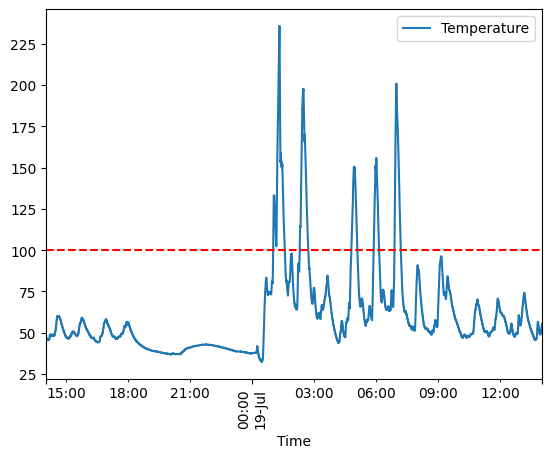

In [264]:
ax = panelek.loc(0)[:, 6].reset_index().plot(x="Time", y="Temperature")
ax.axhline(y=100, color='red', linestyle='--')
ax.tick_params(axis='x', rotation=90)
None

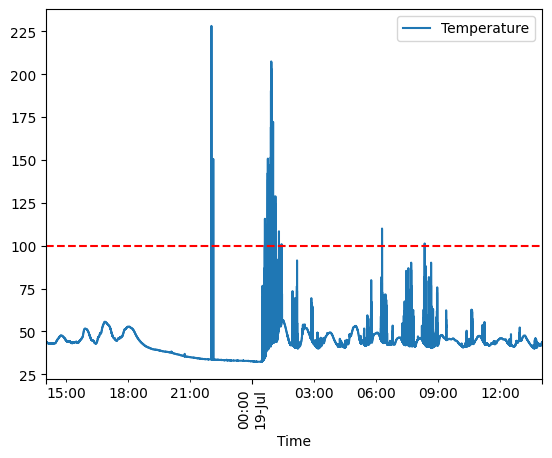

In [265]:
ax = panelek.loc(0)[:, 11].reset_index().plot(x="Time", y="Temperature")
ax.axhline(y=100, color='red', linestyle='--')
ax.tick_params(axis='x', rotation=90)
None

In [266]:
%%sql

select
    adag_id,
    round(max(temperature), 2) as max_temperature,
    panel
from (
    select 
        time, 
        panel,
        temperature,
        `ADAGSZÁM` as adag_id
        from panelek
        left join adagok 
        on panelek.time between adagok.Kezdet and adagok.Vége
)
group by adag_id, panel
having max(temperature) >= 100;

 * sqlite:///data/data.db
Done.


adag_id,max_temperature,panel
17,235.8,6
17,228.2,11
18,197.6,6
19,117.8,6
20,150.5,6
21,155.8,6
22,200.8,6
22,110.0,11
23,148.5,6
24,101.3,11


In [267]:
%%sql

select
    adag_id,
    panel,
    round(max(temperature), 2) as max_temperature,
    round(min(temperature), 2) as min_temperature,
    round(avg(temperature), 2) as avg_temperature
from (
    select 
        time, 
        panel,
        temperature,
        `ADAGSZÁM` as adag_id
        from panelek
        left join adagok 
        on panelek.time between adagok.Kezdet and adagok.Vége
)
group by adag_id, panel
-- having max(temperature) >= 100
order by adag_id, panel;

 * sqlite:///data/data.db
Done.


adag_id,panel,max_temperature,min_temperature,avg_temperature
13,1,46.7,40.4,42.99
13,2,36.0,34.9,35.37
13,3,42.3,36.3,38.64
13,4,46.0,35.2,42.41
13,5,44.6,40.8,42.7
13,6,60.1,45.5,51.49
13,8,42.9,38.9,40.32
13,9,42.9,39.1,40.31
13,10,48.9,40.0,43.09
13,11,47.6,42.9,44.08


In [268]:
print(f"adagok     : {adagok.Kezdet.min()}-- {adagok.Vége.max()}")
print(f"hűtőpanelek: {hutopanelek.Time.min()}-- {hutopanelek.Time.max()}")


adagok     : 2024-07-17 17:49:00-- 2024-07-19 23:09:00
hűtőpanelek: 2024-07-18 14:01:52-- 2024-07-19 14:01:51


In [269]:
%%sql
select * from adagok limit 5;

 * sqlite:///data/data.db
Done.


ADAGSZÁM,Kezdet,Vége
1,2024-07-17 17:49:00,2024-07-18 01:00:00
2,2024-07-18 01:00:00,2024-07-18 02:22:00
3,2024-07-18 02:22:00,2024-07-18 03:36:00
4,2024-07-18 03:36:00,2024-07-18 04:43:00
5,2024-07-18 04:43:00,2024-07-18 05:41:00


In [274]:
%%sql
SELECT
    time, panel,
    Max(Temperature) over (partition by panel order by time) >= 90 as hot,
    Min(Temperature) over (partition by panel order by time) >= 90 as hot2
FROM panelek
LIMIT 10;



 * sqlite:///data/data.db
Done.


Time,Panel,hot,hot2
2024-07-18 14:01:52,1,0,0
2024-07-18 14:01:53,1,0,0
2024-07-18 14:01:54,1,0,0
2024-07-18 14:01:55,1,0,0
2024-07-18 14:01:56,1,0,0
2024-07-18 14:01:57,1,0,0
2024-07-18 14:01:58,1,0,0
2024-07-18 14:01:59,1,0,0
2024-07-18 14:02:00,1,0,0
2024-07-18 14:02:01,1,0,0


In [272]:
%%sql
SELECT 6 as Panel, COUNT(*) AS Count FROM panelek 
WHERE  Panel = 6 AND Temperature >= 100
union
SELECT 11 as Panel, COUNT(*) AS Count FROM panelek
WHERE  Panel = 11 AND Temperature >= 100

 * sqlite:///data/data.db
Done.


Panel,Count
6,6615
11,285


In [273]:
%%sql
SELECT Panel, COUNT(*) AS Count
FROM panelek
WHERE Temperature >= 100
GROUP BY Panel;

 * sqlite:///data/data.db
Done.


Panel,Count
6,6615
11,285
